In [1]:
# Run this cell to set up packages for lecture.
from lec06_imports import *
%reload_ext pandas_tutor

# Lecture 6 – Data Visualization 📈
## DSC 10, Winter 2026

### Agenda

- Recap: Grouping.
- Adjusting columns.
- Why visualize?
- Terminology.
- Scatter plots.
- Line plots.
- Bar charts.

### 💡 Pro-Tip: Using Pandas Tutor

Pandas Tutor (built by Sam Lau) is pre-installed on DataHub. It visualizes the 
last line of a Jupyter cell. To use it, there are two steps:

1. Add the line `%reload_ext pandas_tutor` to the top of your notebook and run it (notice that we already did that in this notebook).
2. To visualize a cell, add `%%pt` to the top of the cell:

In [2]:
%%pt

df = bpd.read_csv('data/dogs_small.csv')
df.get(['size', 'longevity']).groupby('size').mean()

### Aside: Keyboard shortcuts

There are several keyboard shortcuts built into Jupyter Notebooks designed to help you save time. To see them, either click the keyboard button in the toolbar above or hit the H key on your keyboard (as long as you're not actively editing a cell).

Particularly useful shortcuts:

| Action | Keyboard shortcut |
| --- | --- |
| Run cell + jump to next cell | SHIFT + ENTER |
| Save the notebook | CTRL/CMD + S |
| Create new cell above/below | A/B |
| Delete cell | DD |

## Recap: Grouping

### The data: US states  🗽

We'll continue working with the same data from last time.

In [3]:
states = bpd.read_csv('data/states.csv')
states = states.assign(Density=states.get('Population') / states.get('Land Area'))
states = states.set_index('State')
states

,Region,Capital City,Population,Land Area,Party,Density
State,,,,,,
Alabama,South,Montgomery,5024279,50645,Republican,99.21
Alaska,West,Juneau,733391,570641,Republican,1.29
Arizona,West,Phoenix,7151502,113594,Republican,62.96
...,...,...,...,...,...,...
West Virginia,South,Charleston,1793716,24038,Republican,74.62
Wisconsin,Midwest,Madison,5893718,54158,Republican,108.82
Wyoming,West,Cheyenne,576851,97093,Republican,5.94


### `.groupby` aggregates rows

`.groupby` aggregates (collects) all rows with the same value in a specified column (e.g. `'Region'`) into a single row in the resulting DataFrame, using an aggregation method (e.g. `.sum()`) to combine values from different rows with the same value in the specified column.

In [4]:
states.get(['Region', 'Population']).groupby('Region').sum()

,Population
Region,
Midwest,68985454
Northeast,57609148
South,125576562
West,78588572


### Using `.groupby` in general

In short, `.groupby` aggregates (collects) all rows with the same value in a specified column (e.g. `'Region'`) into a single row in the resulting DataFrame, using an aggregation method (e.g. `.sum()`) to combine values from different rows with the same value in the specified column.

To use `.groupby`:

1. **Choose a column to group by and column(s) to aggregate with `.get()`**.
    - `.get(['Region', 'Population', ...])` to select out the columns you want to group by and aggregate together.
    - Rule of thumb:
        - Choose one categorical column to group by (in this case, `Region`).
        - Choose one or more numeric columns to aggregate (`Population`, `Land Area`, etc.)
        - Don't include non-numeric columns to aggregate unless your aggregation method doesn't perform arithmetic (e.g. `.count()` is okay on string columns, but not `.mean()`).

2. **Make groups with `.groupby()`**.
    - `.groupby(column_name)` will gather rows which have the same value in the specified column (`column_name`).
    - In the resulting DataFrame, there will be one row for every unique value in that column.

3. **Call an aggregation method**.
    - The aggregation method will be applied **within** each group.
    - The aggregation method is applied individually to each column.
        - If it doesn't make sense to use the aggregation method on a column, you will get an error or nonsensical result.
    - Common aggregation methods include `.count()`, `.sum()`, `.mean()`, `.median()`, `.max()`, and `.min()`.

In [5]:
(states
    # Step 1
    .get(['Region', 'Population'])
    # Step 2
    .groupby('Region')
    # Step 3
    .sum()
)

,Population
Region,
Midwest,68985454
Northeast,57609148
South,125576562
West,78588572


## Adjusting columns

### `.count()` 

Notice the column names don't make sense after grouping with the `.count()` aggregation method.

In [6]:
states.groupby('Region').count()

,Capital City,Population,Land Area,Party,Density
Region,,,,,
Midwest,12,12,12,12,12
Northeast,9,9,9,9,9
South,16,16,16,16,16
West,13,13,13,13,13


## Why visualize?

### Little Women

In Lecture 1, we were able to answer questions about the plot of _Little Women_ without having to read the novel and without having to understand Python code. Some of those questions included:

- Who is the main character?
- Which pair of characters gets married at the end?

We answered these questions from a data visualization alone!

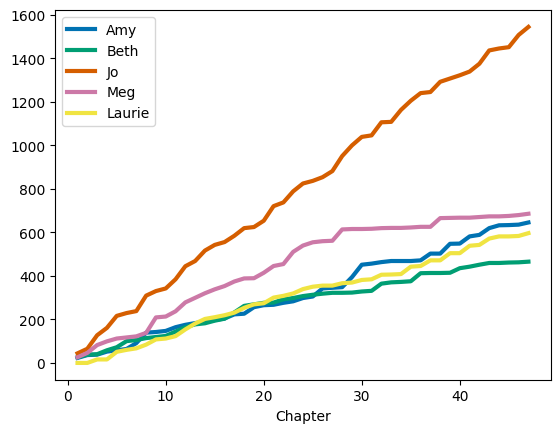

In [7]:
bpd.read_csv('data/lw_counts.csv').plot(x='Chapter', linewidth=3.0);

### Why visualize?

- Computers are better than humans at crunching numbers, but humans are better at identifying visual patterns.

- Visualizations allow us to understand lots of data quickly – they make it easier to spot trends and communicate our results with others.

- There are many types of visualizations; in this class, we'll look at scatter plots, line plots, bar charts, and histograms, but there are many others.
    - The right choice depends on the type of data.

## Terminology

### Individuals and variables

<center><img src='images/states-indiv-var.png' width=1000/></center>

- <span style="color:#6d9eeb"><b>Individual (row)</b></span>: Person/place/thing for which data is recorded. Also called an **observation**.

- <span style="color:#ff9900"><b>Variable (column)</b></span>: Something that is recorded for each individual. Also called a **feature**.

### Types of variables

There are two main types of variables:

- **Numerical**: It makes sense to do arithmetic with the values.
- **Categorical**: Values fall into categories, that may or may not have some _order_ to them.

Note that here, "variable" does not mean a variable in Python, but rather it means a column in a DataFrame.

### Examples of numerical variables

- Salaries of NBA players 🏀.
    - Individual: An NBA player.
    - Variable: Their salary.

- Company's annual profit 💰.
    - Individual: A company.
    - Variable: Its annual profit.

- Flu shots administered per day 💉.
    - Individual: Date.
    - Variable: Number of flu shots administered on that date.

### Examples of categorical variables

- Movie genres 🎬.
    - Individual: A movie.
    - Variable: Its genre.

- Zip codes 🏠.
    - Individual: US resident.
    - Variable: Zip code.
        - Even though they look like numbers, zip codes are categorical (arithmetic doesn't make sense).

- Level of prior programming experience for students in DSC 10 🧑‍🎓.
    - Individual: Student in DSC 10.
    - Variable: Their level of prior programming experience, e.g. none, low, medium, or high. 
        - There is an _order_ to these categories!

### Concept Check ✅ – Answer at [cc.dsc10.com](http://cc.dsc10.com) 

Which of these is **not** a numerical variable?

A. Fuel economy in miles per gallon.

B. Number of quarters at UCSD.

C. College at UCSD (Sixth, Seventh, etc).

D. Bank account number.

E. More than one of these are not numerical variables.

### Types of visualizations

The type of visualization we create depends on the kinds of variables we're visualizing.

- **Scatter plot**: Numerical vs. numerical.
- **Line plot**: Sequential numerical (time) vs. numerical.
- **Bar chart**: Categorical vs. numerical.
- **Histogram**: Numerical.
    - Will cover next time.
    
We may interchange the words "plot", "chart", and "graph"; they all mean the same thing.

## Scatter plots

### The data: exoplanets discovered by NASA 🪐

An [exoplanet](https://exoplanets.nasa.gov/what-is-an-exoplanet/overview/) is a planet outside our solar system. NASA has discovered over 5,000 exoplanets so far in its [search for signs of life beyond Earth](https://exoplanets.nasa.gov/search-for-life/big-questions/). 👽 

|Column |Contents|
|----------|------------|
`'Distance'`| Distance from Earth, in light years.
`'Magnitude'`|	[Apparent magnitude](https://en.wikipedia.org/wiki/Apparent_magnitude#), which measures brightness in such a way that brighter objects have **lower** values.
`'Type'`|  Categorization of planet based on its composition and size.
`'Year'`|	When the planet was discovered.
`'Detection'`|	The method of detection used to discover the planet.
`'Mass'`|	The ratio of the planet's mass to Earth's mass. 
`'Radius'`|  The ratio of the planet's radius to Earth's radius.

In [8]:
exo = bpd.read_csv('data/exoplanets.csv').set_index('Name')
exo

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
11 Comae Berenices b,304.0,4.72,Gas Giant,2007,Radial Velocity,6165.90,11.88
11 Ursae Minoris b,409.0,5.01,Gas Giant,2009,Radial Velocity,4684.81,11.99
14 Andromedae b,246.0,5.23,Gas Giant,2008,Radial Velocity,1525.58,12.65
...,...,...,...,...,...,...,...
YZ Ceti b,12.0,12.07,Terrestrial,2017,Radial Velocity,0.70,0.91
YZ Ceti c,12.0,12.07,Super Earth,2017,Radial Velocity,1.14,1.05
YZ Ceti d,12.0,12.07,Super Earth,2017,Radial Velocity,1.09,1.03


### Scatter plots

- What is the relationship between `'Distance'` and `'Magnitude'`?

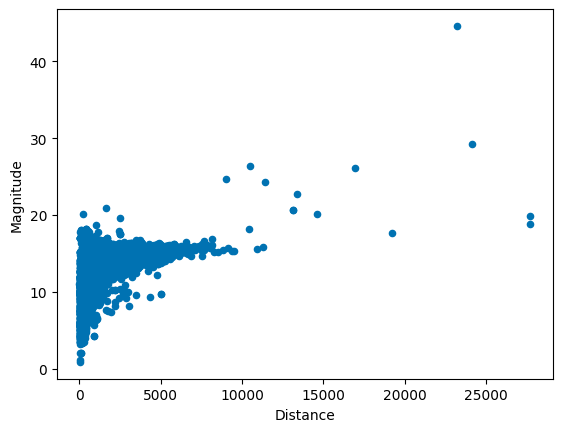

In [9]:
exo.plot(kind='scatter', x='Distance', y='Magnitude');

- Further planets have greater `'Magnitude'` (meaning they are less bright), which makes sense.

- The data appears curved because `'Magnitude'` is measured on a logarithmic scale. A decrease of one unit in `'Magnitude'` corresponds to a 2.5 times increase in brightness.

<center><img src='images/magnitude.png' width=600></center>

### Scatter plots

- Scatter plots visualize the relationship between two numerical variables.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='scatter', 
    x=x_column_for_horizontal, 
    y=y_column_for_vertical
)
```
- The resulting scatter plot has one point per row of `df`.
- If you put a semicolon after a call to `.plot`, it will hide the weird text output that displays.

### Zooming in 🔍

The majority of exoplanets are less than 10,000 light years away; if we'd like to zoom in on just these exoplanets, we can query before plotting.

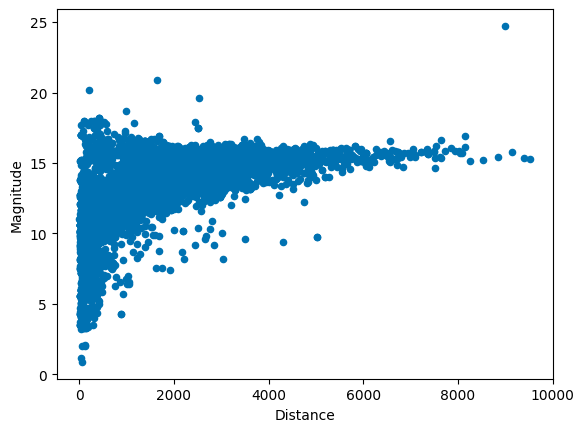

In [10]:
exo[exo.get('Distance') < 10000].plot(kind='scatter', x='Distance', y='Magnitude');

## Line plots 📉

### Line plots

- How has the `'Magnitude'` of newly discovered exoplanets changed over time?

In [11]:
# There were multiple exoplanets discovered each year.
# What operation can we apply to this DataFrame so that there is one row per year?
exo

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
11 Comae Berenices b,304.0,4.72,Gas Giant,2007,Radial Velocity,6165.90,11.88
11 Ursae Minoris b,409.0,5.01,Gas Giant,2009,Radial Velocity,4684.81,11.99
14 Andromedae b,246.0,5.23,Gas Giant,2008,Radial Velocity,1525.58,12.65
...,...,...,...,...,...,...,...
YZ Ceti b,12.0,12.07,Terrestrial,2017,Radial Velocity,0.70,0.91
YZ Ceti c,12.0,12.07,Super Earth,2017,Radial Velocity,1.14,1.05
YZ Ceti d,12.0,12.07,Super Earth,2017,Radial Velocity,1.09,1.03


- Let's calculate the average `'Magnitude'` of all exoplanets discovered in each `'Year'`.

In [12]:
exo.get(['Year', 'Magnitude']).groupby('Year').mean()

,Magnitude
Year,
1995,5.45
1996,5.12
1997,5.41
...,...
2021,13.01
2022,10.62
2023,12.09


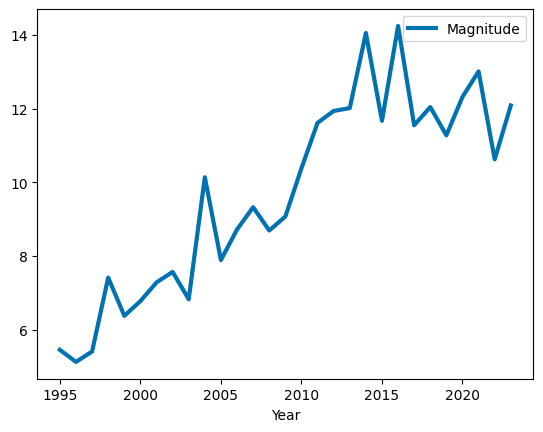

In [13]:
(exo
    .get(['Year', 'Magnitude'])
    .groupby('Year')
    .mean()
    .plot(
        kind='line', 
        y='Magnitude',
        linewidth=3.0)
);

- It looks like the brightest planets were discovered first, which makes sense. 

- NASA's Kepler space telescope began its nine-year mission in 2009, leading to a boom in the discovery of exoplanets.

### Line plots

- Line plots show trends in numerical variables over time.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='line', 
    x=x_column_for_horizontal, 
    y=y_column_for_vertical
)
```
- To use the index as the x-axis, omit the `x=` argument.
    - This doesn't work for scatterplots, but it works for most other plot types.

### Extra video on line plots

If you're curious how line plots work under the hood, watch [this video](https://www.youtube.com/watch?v=glzZ04D1kDg) we made a few quarters ago.

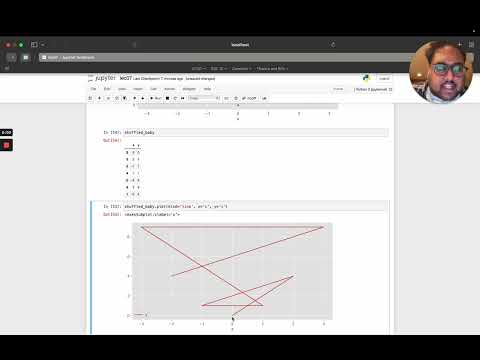

In [14]:
YouTubeVideo('glzZ04D1kDg')

## Bar charts 📊

### Bar charts

- How big are each of the different `'Type'`s of exoplanets, on average?

In [15]:
exo

,Distance,Magnitude,Type,Year,Detection,Mass,Radius
Name,,,,,,,
11 Comae Berenices b,304.0,4.72,Gas Giant,2007,Radial Velocity,6165.90,11.88
11 Ursae Minoris b,409.0,5.01,Gas Giant,2009,Radial Velocity,4684.81,11.99
14 Andromedae b,246.0,5.23,Gas Giant,2008,Radial Velocity,1525.58,12.65
...,...,...,...,...,...,...,...
YZ Ceti b,12.0,12.07,Terrestrial,2017,Radial Velocity,0.70,0.91
YZ Ceti c,12.0,12.07,Super Earth,2017,Radial Velocity,1.14,1.05
YZ Ceti d,12.0,12.07,Super Earth,2017,Radial Velocity,1.09,1.03


In [16]:
types = (exo
    .get(['Type', 'Mass', 'Radius', 'Magnitude', 'Distance'])
    .groupby('Type')
    .mean()
)
types

,Mass,Radius,Magnitude,Distance
Type,,,,
Gas Giant,1472.39,12.74,10.30,1096.40
Neptune-like,15.28,3.11,13.52,2189.02
Super Earth,5.81,1.58,13.85,1916.26
Terrestrial,1.62,0.85,13.45,1373.60


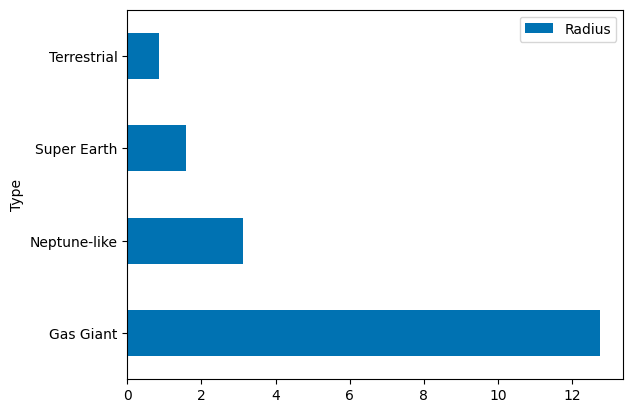

In [17]:
types.plot(kind='barh', y='Radius');

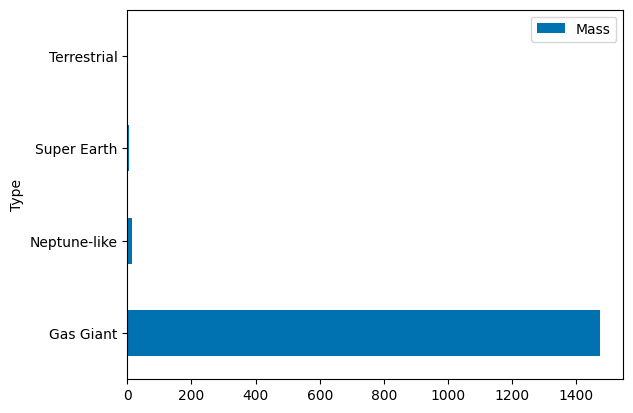

In [18]:
types.plot(kind='barh', y='Mass');

- It looks like the `'Gas Giant'`s are aptly named! 

<center><img src='images/exoplanet_types.jpeg' width=800></center>

### Bar charts

- Bar charts visualize the relationship between a categorical variable and a numerical variable.
- In a bar chart...
    - The thickness and spacing of bars is arbitrary.
    - The order of the categorical labels doesn't matter.
- To create one from a DataFrame `df`, use
```py
df.plot(
    kind='barh', 
    x=categorical_column_name, 
    y=numerical_column_name
)
```
- The **"h"** in `'barh'` stands for **"horizontal"**.
    - It's easier to read labels this way.
- Note that in the previous chart, we set `y='Mass'` even though mass is measured by x-axis length.

### Bar charts and sorting

What are the most popular `'Detection'` methods for discovering exoplanets?

In [19]:
# Count how many exoplanets are discovered by each detection method.
popular_detection = exo.groupby('Detection').count()
popular_detection

,Distance,Magnitude,Type,Year,Mass,Radius
Detection,,,,,,
Astrometry,1,1,1,1,1,1
Direct Imaging,50,50,50,50,50,50
Disk Kinematics,1,1,1,1,1,1
...,...,...,...,...,...,...
Radial Velocity,1019,1019,1019,1019,1019,1019
Transit,3914,3914,3914,3914,3914,3914
Transit Timing Variations,23,23,23,23,23,23


In [20]:
# Give columns more meaningful names and eliminate redundancy.
popular_detection = (popular_detection.assign(Count=popular_detection.get('Distance'))
                                      .get(['Count'])
                                      .sort_values(by='Count', ascending=False)
                    )
popular_detection

,Count
Detection,
Transit,3914
Radial Velocity,1019
Direct Imaging,50
...,...
Astrometry,1
Disk Kinematics,1
Pulsar Timing,1


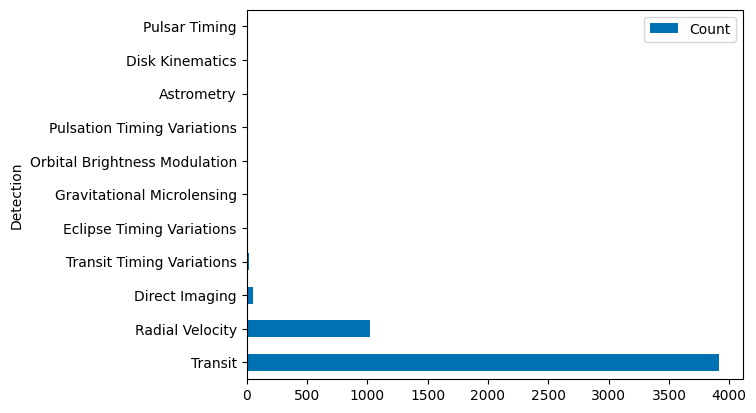

In [21]:
# Notice that the bars appear in the opposite order relative to the DataFrame.
popular_detection.plot(kind='barh', y='Count');

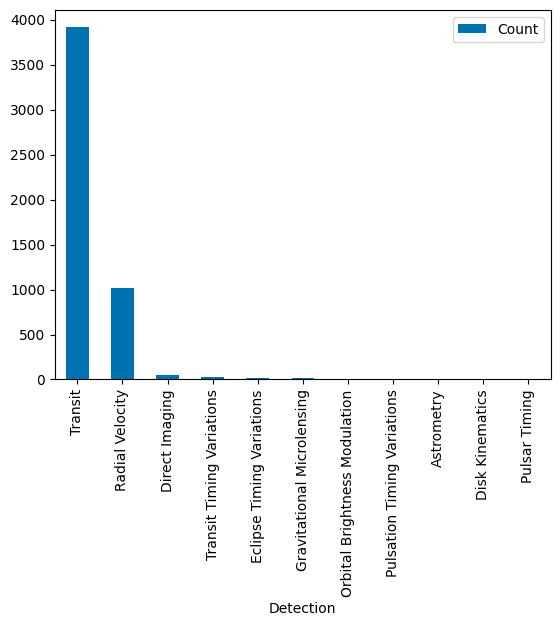

In [22]:
# Change "barh" to "bar" to get a vertical bar chart. 
# These are harder to read, but the bars do appear in the same order as the DataFrame.
popular_detection.plot(kind='bar', y='Count');

### Multiple plots on the same axes

Can we look at both the average `'Magnitude'` and the average `'Radius'` for each `'Type'` at the same time?

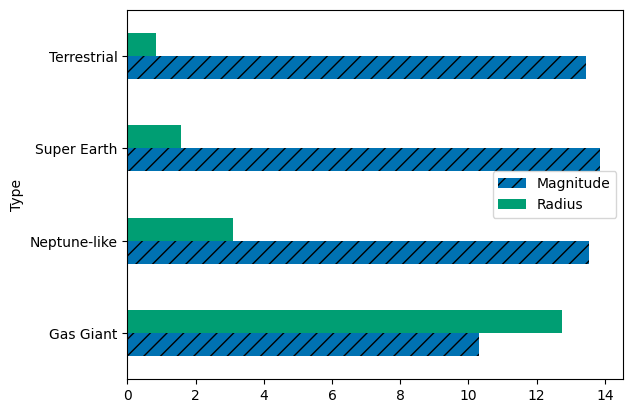

In [23]:
bars = types.get(['Magnitude', 'Radius']).plot(kind='barh');

# Don't worry about understanding this code, we're using it to draw hatch marks
# on the Magnitude bars which is generally good practice for plots to be 
# readable in grayscale.
for i, patch in enumerate(bars.patches):
    if i<4:
        patch.set_hatch('//')
plt.legend();

How did we do that?

### Overlaying plots

When calling `.plot`, if we omit the `y=column_name` argument, **all other columns** are plotted.

In [24]:
types

,Mass,Radius,Magnitude,Distance
Type,,,,
Gas Giant,1472.39,12.74,10.30,1096.40
Neptune-like,15.28,3.11,13.52,2189.02
Super Earth,5.81,1.58,13.85,1916.26
Terrestrial,1.62,0.85,13.45,1373.60


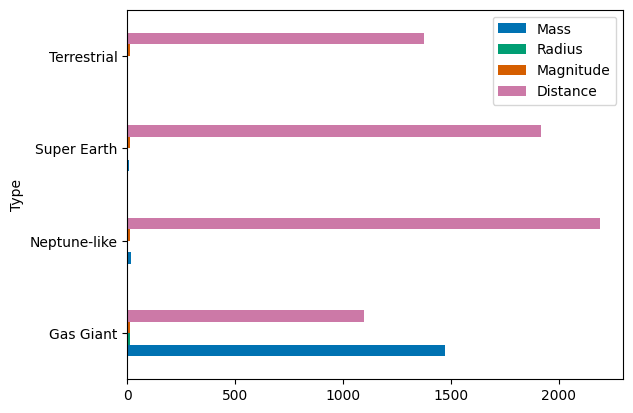

In [25]:
types.plot(kind='barh');

### Selecting multiple columns at once

Remember, to select multiple columns, use `.get([column_1, ..., column_k])`. This returns a DataFrame.

In [26]:
types

,Mass,Radius,Magnitude,Distance
Type,,,,
Gas Giant,1472.39,12.74,10.30,1096.40
Neptune-like,15.28,3.11,13.52,2189.02
Super Earth,5.81,1.58,13.85,1916.26
Terrestrial,1.62,0.85,13.45,1373.60


In [27]:
types.get(['Magnitude', 'Radius'])

,Magnitude,Radius
Type,,
Gas Giant,10.30,12.74
Neptune-like,13.52,3.11
Super Earth,13.85,1.58
Terrestrial,13.45,0.85


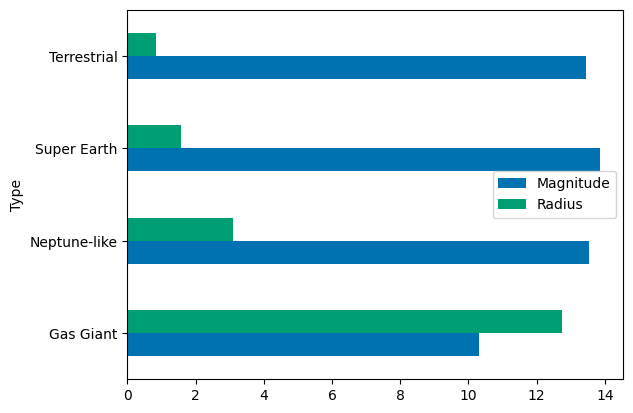

In [28]:
types.get(['Magnitude', 'Radius']).plot(kind='barh');

## Summary

### Summary

- Visualizations make it easy to extract patterns from datasets.
- There are two main types of variables: categorical and numerical.
- The types of the variables we're visualizing inform our choice of which type of visualization to use.
- Today, we looked at scatter plots, line plots, and bar charts.
- **Next time**: histograms.